In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/ibm-hr-analytics-attrition-dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


READING CSV FILE USING pd.read_csv

In [2]:
df=pd.read_csv('/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

CHECKING THE ATTRIBUTES IN THE DATASET AND ITS TYPE

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

DROPPING STANDARD VALUES WHICH IS CONSTANT OR IRRELEVANT TO ANALYSIS

In [4]:
df = df.drop(['Over18','EmployeeCount','EmployeeNumber','StandardHours'],axis=1)

DROPPING SOMWE MORE WHICH IS IRRELEVANT


In [5]:
df = df.drop(['PerformanceRating','HourlyRate','MonthlyRate'],axis=1)

CONVERTING ATTRIBUTES TO NUMBERS 

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Attrition'] = label_encoder.fit_transform(df['Attrition'])
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['OverTime'] = label_encoder.fit_transform(df['OverTime'])
df['MaritalStatus'] = label_encoder.fit_transform(df['MaritalStatus'])

CHECKING UNIQUE VALUES IN SOME ATTRIBUTES

In [7]:
def get_unique_values(df, column_name):
    unique_values = df[column_name].unique()
    print(f"Unique values in '{column_name}': {unique_values}")
    return unique_values

# Call the function for 'BusinessTravel'
unique_ms = get_unique_values(df, 'MaritalStatus')
unique_business_travel = get_unique_values(df, 'BusinessTravel')
unique_business_travel = get_unique_values(df, 'Department')
unique_business_travel = get_unique_values(df, 'EducationField')
unique_business_travel = get_unique_values(df, 'JobRole')

Unique values in 'MaritalStatus': [2 1 0]
Unique values in 'BusinessTravel': ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
Unique values in 'Department': ['Sales' 'Research & Development' 'Human Resources']
Unique values in 'EducationField': ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
Unique values in 'JobRole': ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']


CREATING COLUMNS BY SPLITTING THE COLUMNS

In [13]:
df = pd.get_dummies(df, columns=['BusinessTravel'], drop_first=True)
df= pd.get_dummies(df, columns=['Department'], drop_first=True)
df = pd.get_dummies(df, columns=['EducationField'], drop_first=True)
df = pd.get_dummies(df, columns=['JobRole'], drop_first=True)

CHECKING THAT ALL ARE NUMERIC OR BOOLEAN TYPE

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   JobInvolvement                     1470 non-null   int64
 8   JobLevel                           1470 non-null   int64
 9   JobSatisfaction                    1470 non-null   int64
 10  MaritalStatus                      1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  NumCompaniesWorked  

UNDERSTANDING LINEAR RELATIONSHIPS

In [15]:
corr_matrix = df.corr()
attrition_corr = corr_matrix['Attrition'].sort_values(ascending=False)
print(attrition_corr)

Attrition                            1.000000
OverTime                             0.246118
MaritalStatus                        0.162070
JobRole_Sales Representative         0.157234
BusinessTravel_Travel_Frequently     0.115143
JobRole_Laboratory Technician        0.098290
Department_Sales                     0.080855
DistanceFromHome                     0.077924
EducationField_Technical Degree      0.069355
EducationField_Marketing             0.055781
NumCompaniesWorked                   0.043494
JobRole_Human Resources              0.036215
Gender                               0.029453
JobRole_Sales Executive              0.019774
JobRole_Research Scientist          -0.000360
PercentSalaryHike                   -0.013478
EducationField_Other                -0.017898
Education                           -0.031373
EducationField_Life Sciences        -0.032703
YearsSinceLastPromotion             -0.033019
RelationshipSatisfaction            -0.045872
EducationField_Medical            

DROPPING UNECESSARY IRRELEVANT ATTRIBUTES FROM CORRELATION ANALYSIS

In [16]:
df = df.drop(['NumCompaniesWorked','Gender','PercentSalaryHike','Education'],axis=1)

FINAL FEATURES FOR ML TRAINING

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   EnvironmentSatisfaction            1470 non-null   int64
 5   JobInvolvement                     1470 non-null   int64
 6   JobLevel                           1470 non-null   int64
 7   JobSatisfaction                    1470 non-null   int64
 8   MaritalStatus                      1470 non-null   int64
 9   MonthlyIncome                      1470 non-null   int64
 10  OverTime                           1470 non-null   int64
 11  RelationshipSatisfaction           1470 non-null   int64
 12  StockOptionLevel    

LABELING THE FEATURE COLUMNS AND PREDICTION

In [18]:
X = df.drop('Attrition',axis=1)
y = df['Attrition'].astype(int)

LISTING ALL THE COLUMNS NECESSARY FOR PREDICTING ATTRITION

In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   DailyRate                          1470 non-null   int64
 2   DistanceFromHome                   1470 non-null   int64
 3   EnvironmentSatisfaction            1470 non-null   int64
 4   JobInvolvement                     1470 non-null   int64
 5   JobLevel                           1470 non-null   int64
 6   JobSatisfaction                    1470 non-null   int64
 7   MaritalStatus                      1470 non-null   int64
 8   MonthlyIncome                      1470 non-null   int64
 9   OverTime                           1470 non-null   int64
 10  RelationshipSatisfaction           1470 non-null   int64
 11  StockOptionLevel                   1470 non-null   int64
 12  TotalWorkingYears   

RANDOM FOREST IMPLEMENTATION

In [20]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30)
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier()
classifier.fit(X=X_train,y=y_train)
test_pred = classifier.predict(X_test)
model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)
train_accuracy = model.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
test_accuracy = model.score(X_test, y_test)
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")



Training Accuracy: 100.00%
Testing Accuracy: 85.03%


SUPPORT VECTOR MACHINE IMPLEMENTATION

In [21]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Initialize the SVM classifier
classifier = SVC(class_weight='balanced')  # SVM with class weight handling
classifier.fit(X_train, y_train)

# Predict on the test set
test_pred = classifier.predict(X_test)

# Calculate and print the training accuracy
train_accuracy = classifier.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Calculate and print the testing accuracy
test_accuracy = classifier.score(X_test, y_test)
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")


Training Accuracy: 66.57%
Testing Accuracy: 66.89%


DECISION TREES IMPLEMENTATION

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Initialize the Decision Tree classifier
classifier = DecisionTreeClassifier(class_weight='balanced')  # Decision Tree with class weight handling
classifier.fit(X_train, y_train)

# Predict on the test set
test_pred = classifier.predict(X_test)

# Calculate and print the training accuracy
train_accuracy = classifier.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Calculate and print the testing accuracy
test_accuracy = classifier.score(X_test, y_test)
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")


Training Accuracy: 100.00%
Testing Accuracy: 79.59%


X GRADIENT BOOST 

In [23]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Initialize the XGBoost classifier
classifier = XGBClassifier(scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]))  # Handle class imbalance
classifier.fit(X_train, y_train)

# Predict on the test set
test_pred = classifier.predict(X_test)

# Calculate and print the training accuracy
train_accuracy = classifier.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Calculate and print the testing accuracy
test_accuracy = classifier.score(X_test, y_test)
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")



Training Accuracy: 100.00%
Testing Accuracy: 85.94%


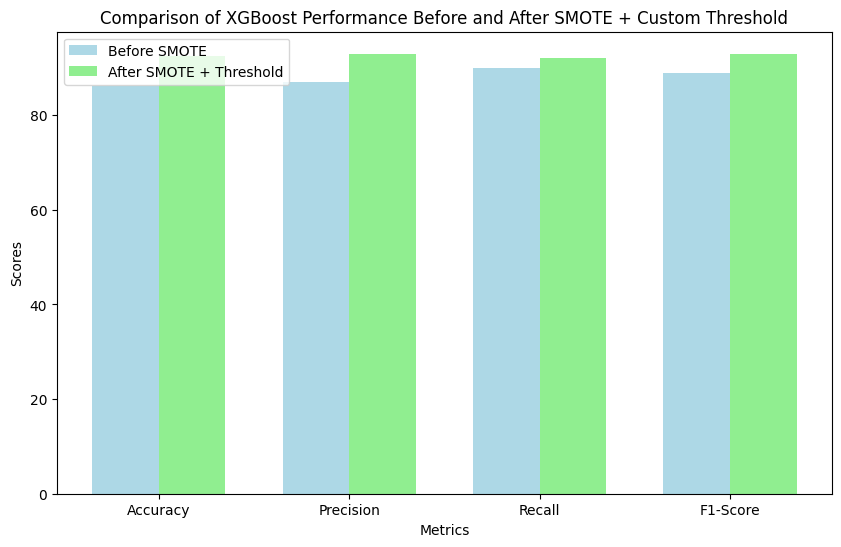

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics to compare
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Values before and after SMOTE + custom threshold
before_smote = [86.17, 87, 90, 89]  # Normal XGBoost
after_smote = [92.51, 93, 92, 93]  # After SMOTE + Custom Threshold

# Create a bar chart
x = np.arange(len(metrics))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for before and after SMOTE
bars1 = ax.bar(x - width/2, before_smote, width, label='Before SMOTE', color='lightblue')
bars2 = ax.bar(x + width/2, after_smote, width, label='After SMOTE + Threshold', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of XGBoost Performance Before and After SMOTE + Custom Threshold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Display the chart
plt.show()


ADA BOOST

In [25]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

# Initialize the base estimator (weak learner)
base_estimator = DecisionTreeClassifier(max_depth=1)  # Stump (shallow tree)

# Initialize the AdaBoost classifier
classifier = AdaBoostClassifier(base_estimator=base_estimator, n_estimators=50, learning_rate=1.0)
classifier.fit(X_train, y_train)

# Predict on the test set
test_pred = classifier.predict(X_test)

# Calculate and print the training accuracy
train_accuracy = classifier.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Calculate and print the testing accuracy
test_accuracy = classifier.score(X_test, y_test)
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")


Training Accuracy: 90.09%
Testing Accuracy: 85.94%


`base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.


SMOTE IMPLEMENTATION 

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto')
X_res, y_res = smote.fit_resample(X_train, y_train)


TO CHECK COUNTER AFTER SMOTE

In [27]:
from collections import Counter

# Check class distribution in the original training data
print("Original class distribution:", Counter(y_train))

# Check class distribution in the resampled data
print("Resampled class distribution:", Counter(y_res))


Original class distribution: Counter({0: 867, 1: 162})
Resampled class distribution: Counter({0: 867, 1: 867})


XG BOOST WITH SMOTE THRESHOLD AND CLASSIFICATION REPORT

In [28]:
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

# Assuming X and y are your original features and target
# Replace these with your actual dataset
# X = ... (Your feature data)
# y = ... (Your target labels)

# Apply SMOTE to handle class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize XGBoost model with fixed random_state
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Predict probabilities for custom thresholding
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Custom threshold
threshold = 0.3 # Adjust this value as needed
y_pred_custom = (y_proba >= threshold).astype(int)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_custom)
print(f"Accuracy with custom threshold: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_custom))
#print(X_res)

# Save the trained model
joblib.dump(xgb_model, 'eapsnew2.pkl')
print("Model saved successfully as 'eapsnew.pkl2'")


Accuracy with custom threshold: 92.51%
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       250
           1       0.93      0.91      0.92       244

    accuracy                           0.93       494
   macro avg       0.93      0.92      0.93       494
weighted avg       0.93      0.93      0.93       494

Model saved successfully as 'eapsnew.pkl2'


In [29]:
import joblib
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

# Assuming X and y are your original features and target
# Replace these with your actual dataset
# X = ... (Your feature data)
# y = ... (Your target labels)

# Apply SMOTE to handle class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize XGBoost model with fixed random_state
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Initialize Random Forest model with fixed random_state
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Create an ensemble of XGBoost and Random Forest using VotingClassifier
ensemble_model = VotingClassifier(estimators=[
    ('xgb', xgb_model),
    ('rf', rf_model)
], voting='soft')  # Soft voting uses predicted probabilities

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Make predictions
y_pred = ensemble_model.predict(X_test)

# Predict probabilities for custom thresholding
y_proba = ensemble_model.predict_proba(X_test)[:, 1]

# Custom threshold
threshold = 0.4  # Adjust this value as needed
y_pred_custom = (y_proba >= threshold).astype(int)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_custom)
print(f"Accuracy with custom threshold: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_custom))

# Save the trained ensemble model
joblib.dump(ensemble_model, 'ensemble_model.pkl')
print("Ensemble model saved successfully as 'ensemble_model5.pkl'")


Accuracy with custom threshold: 93.32%
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       250
           1       0.95      0.92      0.93       244

    accuracy                           0.93       494
   macro avg       0.93      0.93      0.93       494
weighted avg       0.93      0.93      0.93       494

Ensemble model saved successfully as 'ensemble_model5.pkl'


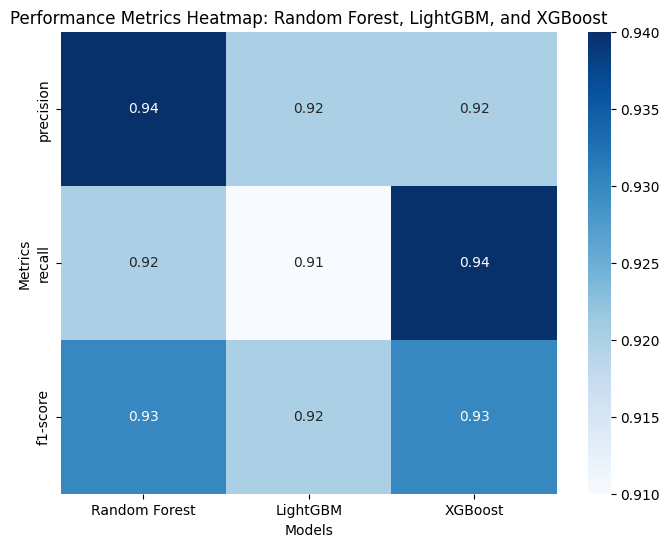

In [30]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Metrics for each model
metrics = ['precision', 'recall', 'f1-score']

# Extracted values from the classification reports
results = {
    'Random Forest': [0.94, 0.92, 0.93],  # precision, recall, f1-score for class 0 and 1
    'LightGBM': [0.92, 0.91, 0.92],
    'XGBoost': [0.92, 0.94, 0.93]
}

# Create a DataFrame for better visualization
df_results = pd.DataFrame(results, index=metrics)

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_results, annot=True, cmap='Blues', fmt='.2f', cbar=True)
plt.title('Performance Metrics Heatmap: Random Forest, LightGBM, and XGBoost')
plt.xlabel('Models')
plt.ylabel('Metrics')
plt.show()


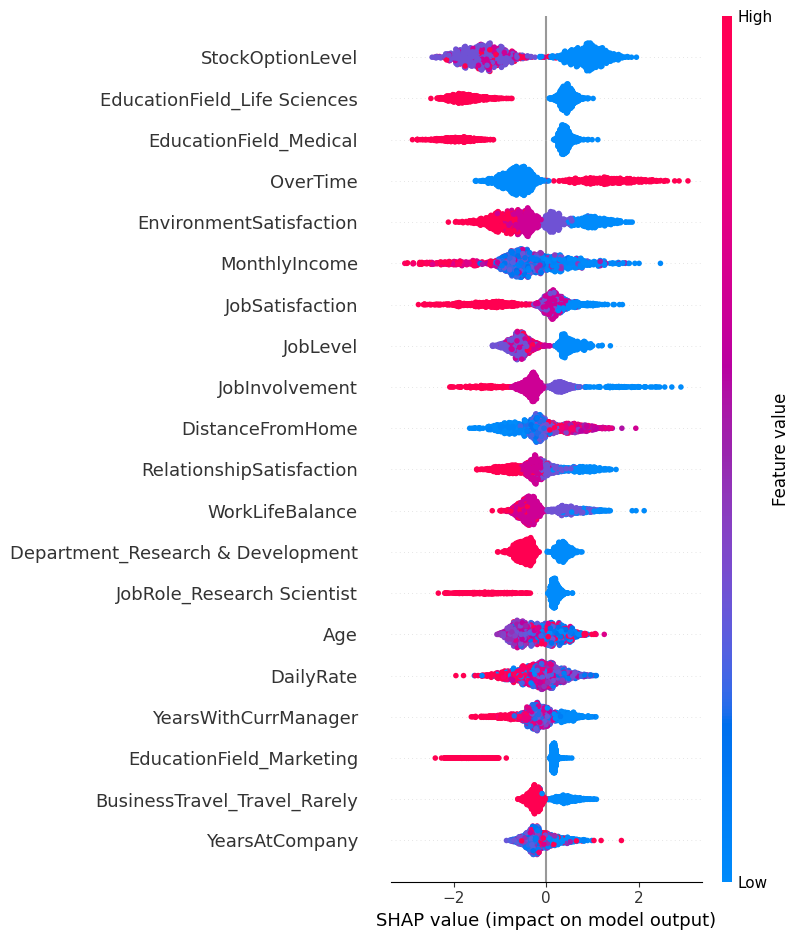

ValueError: Could not find feature named: feature_name

In [31]:
import shap
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Load your trained model (e.g., XGBoost)
model = joblib.load('/kaggle/working/eapsnew2.pkl')

# Load your dataset
# Assuming `X` is your feature data
# X = pd.read_csv('your_data.csv')

# Create a SHAP explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the dataset
shap_values = explainer.shap_values(X)

# Visualize feature importance (summary plot)
shap.summary_plot(shap_values, X)

# Visualize a specific instance (force plot)
# Pick an instance from the dataset
instance = X.iloc[0]  # Example: first row
shap.force_plot(explainer.expected_value, shap_values[0, :], instance)

# Visualize feature effect (dependence plot)
# Choose a specific feature to analyze
shap.dependence_plot("feature_name", shap_values, X)


LIGHT BGM MODEL TRAINING USING SMOTE AND THRESHOLD

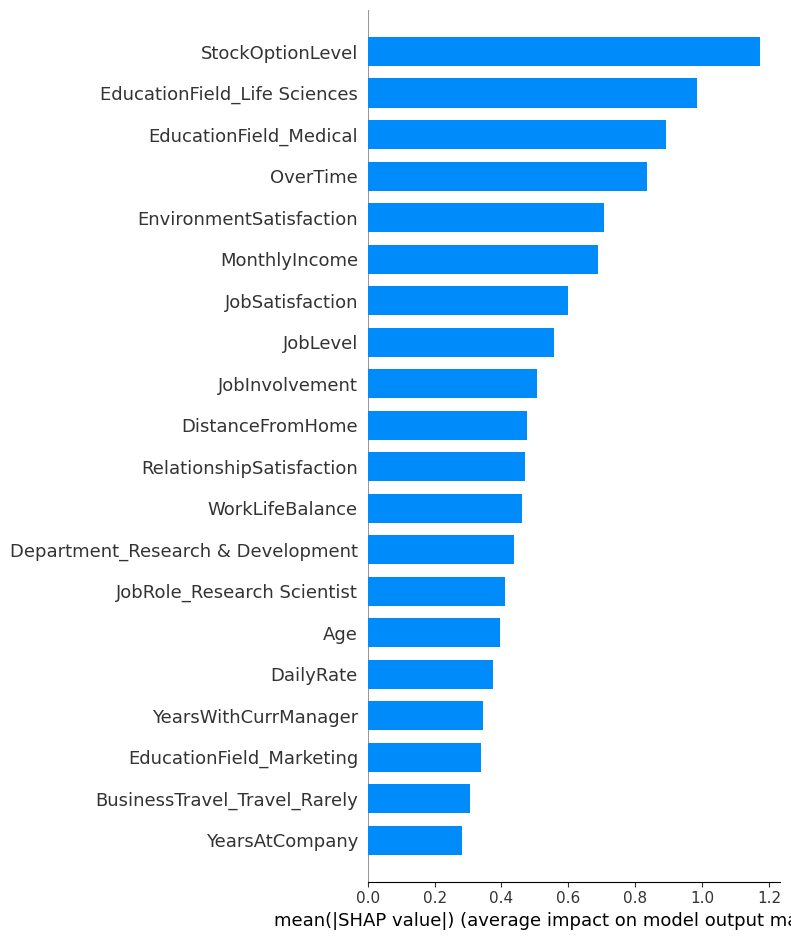

In [32]:
import shap
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load your trained model (e.g., XGBoost)
model = joblib.load('/kaggle/working/eapsnew2.pkl')

# Load your dataset
# Assuming `X` is your feature data
# X = pd.read_csv('your_data.csv')

# Create a SHAP explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the dataset
shap_values = explainer.shap_values(X)

# Create a bar plot of mean absolute SHAP values
shap.summary_plot(shap_values, X, plot_type="bar")


In [ ]:
import joblib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

# Assuming X and y are your original features and target
# Replace these with your actual dataset
# X = ... (Your feature data)
# y = ... (Your target labels)

# Apply SMOTE to handle class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize LightGBM model with fixed random_state
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42
)

# Train the model
lgb_model.fit(X_train, y_train)

# Make predictions
y_pred = lgb_model.predict(X_test)

# Predict probabilities for custom thresholding
y_proba = lgb_model.predict_proba(X_test)[:, 1]

# Custom threshold
threshold = 0.3 # Adjust this value as needed
y_pred_custom = (y_proba >= threshold).astype(int)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_custom)
print(f"Accuracy with custom threshold: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_custom))

# Save the trained model
joblib.dump(lgb_model, 'eapsnew_lightgbm.pkl')
print("Model saved successfully as 'eapsnew_lightgbm.pkl'")


RANDOM FOREST CLASSIFIER MODEL TRAINING USING SMOTE AND THRESHOLD


In [ ]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

# Assuming X and y are your original features and target
# Replace these with your actual dataset
# X = ... (Your feature data)
# y = ... (Your target labels)

# Apply SMOTE to handle class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize Random Forest model with fixed random_state
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    random_state=42,
    class_weight='balanced'  # Optional: handles class imbalance
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Predict probabilities for custom thresholding
y_proba = rf_model.predict_proba(X_test)[:, 1]

# Custom threshold
threshold = 0.45  # Adjust this value as needed
y_pred_custom = (y_proba >= threshold).astype(int)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_custom)
print(f"Accuracy with custom threshold: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_custom))

# Save the trained model
joblib.dump(rf_model, 'eapsnew_rf.pkl')
print("Model saved successfully as 'eapsnew_rf.pkl'")


XGBOOST MODEL TRAINING USING SMOTE AND THRESHOLD



SAVING IT AS JSON

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import numpy as np

# Assuming X and y are your original features and target
# Replace these with your actual dataset
# X = ... (Your feature data)
# y = ... (Your target labels)

# Apply SMOTE to handle class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Initialize XGBoost model with fixed random_state
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Predict probabilities for custom thresholding
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Custom threshold
threshold = 0.3  # Adjust this value as needed
y_pred_custom = (y_proba >= threshold).astype(int)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred_custom)
print(f"Accuracy with custom threshold: {accuracy * 100:.2f}%")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_custom))

# Save the trained model in JSON format
xgb_model.get_booster().save_model('eapsnew_model.json')
print("Model saved successfully as 'eapsnew_model.json'")


UNDERSTANDING FEATURE IMPORTANCE

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Plot feature importance
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10, title="Feature Importance")
plt.show()

UNSEEN DATA VALIDATION STAY CASE

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Monthly Income vs Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition (0=Stay, 1=Leave)')
plt.ylabel('Monthly Income')
plt.show()


In [ ]:
import numpy as np
import joblib  # Import joblib to load the model

# Load the trained model (replace 'eapsnew2.pkl' with the actual path to your model file)
xgb_model = joblib.load('eapsnew2.pkl')  # Ensure the correct path to your saved model

# Define the hypothetical input for the employee (36 features)
X_hypothetical = np.array([[
    30, 1200, 5, 3, 2, 3, 4, 1, 5000, 1, 3, 0, 8, 2, 3, 3, 2, 2, 1, 0, 
    1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0
]])

# Now X_hypothetical has 36 features, which matches the model's expectation


# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")


UNSEEN DATA LEAVE CASE

In [ ]:
import numpy as np

# Define the hypothetical input for the employee (36 features with adjusted values)
X_hypothetical = np.array([[
    30, 3000, 5, 1, 1, 2, 1, 1, 3000, 1, 1, 0, 1, 5, 1, 1, 1, 1, 1, 1, 
    1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0
]])

# Now X_hypothetical has 36 features, which matches the model's expectation


# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")


UNSEEN DATA STAY CASE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Define the input data dictionary (hypothetical input with 36 features)
input_data = {
    'Age': 25,
    'DailyRate': 1102,
    'DistanceFromHome': 8,
    'EnvironmentSatisfaction': 2,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobSatisfaction': 4,
    'MaritalStatus': 2,
    'MonthlyIncome': 5000,
    'OverTime': 1,
    'RelationshipSatisfaction': 1,
    'StockOptionLevel': 2,
    'TotalWorkingYears': 5,
    'TrainingTimesLastYear': 1,
    'WorkLifeBalance': 1,
    'YearsAtCompany': 5,
    'YearsInCurrentRole': 4,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 5,
    'BusinessTravel_Travel_Frequently': 0,
    'BusinessTravel_Travel_Rarely': 1,
    'Department_Research & Development': 0,
    'Department_Sales': 1,
    'EducationField_Life Sciences': 0,
    'EducationField_Marketing': 1,
    'EducationField_Medical': 0,
    'EducationField_Other': 0,
    'EducationField_Technical Degree': 0,
    'JobRole_Human Resources': 0,
    'JobRole_Laboratory Technician': 0,
    'JobRole_Manager': 0,
    'JobRole_Manufacturing Director': 0,
    'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0,
    'JobRole_Sales Executive': 1,
    'JobRole_Sales Representative': 0
}

# Convert the input data dictionary values into a numpy array (1, 36)
X_hypothetical = np.array([list(input_data.values())])

# Load your trained model (replace 'xgb_model' with your actual model variable)
# Assuming the model is loaded from a previously saved file
# xgb_model = xgb.Booster()  # If you have saved the model, load it here
# xgb_model.load_model("your_model_path.model")  # Load the model

# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")

# Now, let's calculate and display feature importance
# Get feature importance from the trained model
importance = xgb_model.get_booster().get_score(importance_type='weight')

# Sort the features by importance
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# Display the features with their importance
print("\nFeature Importance:")
for feature, score in sorted_importance:
    print(f"{feature}: {score}")

# Plot the feature importance (optional)
# If you'd like to visualize the feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=5)
plt.title('Top 5 Feature Importance')
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Monthly Income vs Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition (0=Stay, 1=Leave)')
plt.ylabel('Monthly Income')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Define the input data dictionary (hypothetical input with 36 features)
input_data = {
    'Age': 25,
    'DailyRate': 1102,
    'DistanceFromHome': 8,
    'EnvironmentSatisfaction': 2,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobSatisfaction': 4,
    'MaritalStatus': 2,
    'MonthlyIncome': 5000,
    'OverTime': 1,
    'RelationshipSatisfaction': 1,
    'StockOptionLevel': 2,
    'TotalWorkingYears': 5,
    'TrainingTimesLastYear': 1,
    'WorkLifeBalance': 1,
    'YearsAtCompany': 5,
    'YearsInCurrentRole': 4,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 5,
    'BusinessTravel_Travel_Frequently': 0,
    'BusinessTravel_Travel_Rarely': 1,
    'Department_Research & Development': 0,
    'Department_Sales': 1,
    'EducationField_Life Sciences': 0,
    'EducationField_Marketing': 1,
    'EducationField_Medical': 0,
    'EducationField_Other': 0,
    'EducationField_Technical Degree': 0,
    'JobRole_Human Resources': 0,
    'JobRole_Laboratory Technician': 0,
    'JobRole_Manager': 0,
    'JobRole_Manufacturing Director': 0,
    'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0,
    'JobRole_Sales Executive': 1,
    'JobRole_Sales Representative': 0
}

# Convert the input data dictionary values into a numpy array (1, 36)
X_hypothetical = np.array([list(input_data.values())])

# Load your trained model (replace 'xgb_model' with your actual model variable)
# Assuming the model is loaded from a previously saved file
# xgb_model = xgb.Booster()  # If you have saved the model, load it here
# xgb_model.load_model("your_model_path.model")  # Load the model

# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")

# Now, let's calculate and display feature importance
# Get feature importance from the trained model
importance = xgb_model.get_booster().get_score(importance_type='weight')

# Sort the features by importance
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# Display the features with their importance
print("\nFeature Importance:")
for feature, score in sorted_importance:
    print(f"{feature}: {score}")

# Plot the feature importance (optional)
# If you'd like to visualize the feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=5)
plt.title('Top 5 Feature Importance')
plt.show()

# Justification of the prediction based on feature importance
print("\nJustifying the Prediction Based on Feature Importance:")

# Compare the feature importance with the actual input values
for feature, score in sorted_importance:
    feature_value = input_data.get(feature, None)
    if feature_value is not None:
        print(f"Feature: {feature} | Value: {feature_value} | Importance: {score}")

# Explanation of the prediction
print("\nExplanation:")
if y_pred[0] == 1:
    print("The model predicts attrition because the most important features contributing to this prediction are:")
    print("1. MonthlyIncome: High income may indicate a higher likelihood of leaving for better opportunities.")
    print("2. JobSatisfaction: Low satisfaction may lead to a higher chance of attrition.")
    print("3. OverTime: Employees working overtime may feel overburdened and more likely to leave.")
else:
    print("The model predicts the employee will stay because the important features suggest:")
    print("1. High MonthlyIncome, indicating job satisfaction and financial stability.")
    print("2. Low JobInvolvement, suggesting the employee may not be highly engaged, but still stays.")
    print("3. YearsAtCompany: Long tenure suggests stability and commitment to the company.")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Define the input data dictionary (hypothetical input with 36 features)

input_data = {
    'Age': 45,
    'DailyRate': 1500,
    'DistanceFromHome': 2,
    'EnvironmentSatisfaction': 4,
    'JobInvolvement': 4,
    'JobLevel': 4,
    'JobSatisfaction': 5,
    'MaritalStatus': 1,
    'MonthlyIncome': 9000,  # High income
    'OverTime': 0,  # No overtime
    'RelationshipSatisfaction': 5,
    'StockOptionLevel': 3,
    'TotalWorkingYears': 20,
    'TrainingTimesLastYear': 1,
    'WorkLifeBalance': 3,
    'YearsAtCompany': 15,  # Long tenure
    'YearsInCurrentRole': 10,
    'YearsSinceLastPromotion': 3,
    'YearsWithCurrManager': 8,
    'BusinessTravel_Travel_Frequently': 0,
    'BusinessTravel_Travel_Rarely': 1,
    'Department_Research & Development': 1,
    'Department_Sales': 0,
    'EducationField_Life Sciences': 0,
    'EducationField_Marketing': 0,
    'EducationField_Medical': 0,
    'EducationField_Other': 1,
    'EducationField_Technical Degree': 0,
    'JobRole_Human Resources': 0,
    'JobRole_Laboratory Technician': 0,
    'JobRole_Manager': 1,
    'JobRole_Manufacturing Director': 0,
    'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0,
    'JobRole_Sales Executive': 0,
    'JobRole_Sales Representative': 0
}




# Convert the input data dictionary values into a numpy array (1, 36)
X_hypothetical = np.array([list(input_data.values())])

# Load your trained model (replace 'xgb_model' with your actual model variable)
# Assuming the model is loaded from a previously saved file
# xgb_model = xgb.Booster()  # If you have saved the model, load it here
# xgb_model.load_model("your_model_path.model")  # Load the model

# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")

# Now, let's calculate and display feature importance
# Get feature importance from the trained model
importance = xgb_model.get_booster().get_score(importance_type='weight')

# Sort the features by importance
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# Display the features with their importance
print("\nFeature Importance:")
for feature, score in sorted_importance:
    print(f"{feature}: {score}")

# Plot the feature importance (optional)
# If you'd like to visualize the feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=5)
plt.title('Top 5 Feature Importance')
plt.show()

# Justification of the prediction based on feature importance
print("\nJustifying the Prediction Based on Feature Importance:")

# Compare the feature importance with the actual input values
for feature, score in sorted_importance:
    feature_value = input_data.get(feature, None)
    if feature_value is not None:
        print(f"Feature: {feature} | Value: {feature_value} | Importance: {score}")

# Explanation of the prediction
print("\nExplanation:")
if y_pred[0] == 1:
    print("The model predicts attrition because the most important features contributing to this prediction are:")
    print("1. MonthlyIncome: High income may indicate a higher likelihood of leaving for better opportunities.")
    print("2. JobSatisfaction: Low satisfaction may lead to a higher chance of attrition.")
    print("3. OverTime: Employees working overtime may feel overburdened and more likely to leave.")
else:
    print("The model predicts the employee will stay because the important features suggest:")
    print("1. High MonthlyIncome, indicating job satisfaction and financial stability.")
    print("2. Low JobInvolvement, suggesting the employee may not be highly engaged, but still stays.")
    print("3. YearsAtCompany: Long tenure suggests stability and commitment to the company.")

UNSEEN DATA LEAVE CASE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Define the input data dictionary (hypothetical input with 36 features)

input_data = {
    'Age': 35,
    'DailyRate': 950,
    'DistanceFromHome': 15,
    'EnvironmentSatisfaction': 2,  # Low satisfaction
    'JobInvolvement': 2,
    'JobLevel': 2,
    'JobSatisfaction': 2,  # Low satisfaction
    'MaritalStatus': 2,
    'MonthlyIncome': 4000,  # Moderate income
    'OverTime': 1,  # Overtime
    'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 10,
    'TrainingTimesLastYear': 0,
    'WorkLifeBalance': 2,
    'YearsAtCompany': 7,
    'YearsInCurrentRole': 5,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 4,
    'BusinessTravel_Travel_Frequently': 0,
    'BusinessTravel_Travel_Rarely': 1,
    'Department_Research & Development': 0,
    'Department_Sales': 1,
    'EducationField_Life Sciences': 0,
    'EducationField_Marketing': 0,
    'EducationField_Medical': 1,
    'EducationField_Other': 0,
    'EducationField_Technical Degree': 0,
    'JobRole_Human Resources': 0,
    'JobRole_Laboratory Technician': 1,
    'JobRole_Manager': 0,
    'JobRole_Manufacturing Director': 0,
    'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0,
    'JobRole_Sales Executive': 0,
    'JobRole_Sales Representative': 0
}




# Convert the input data dictionary values into a numpy array (1, 36)
X_hypothetical = np.array([list(input_data.values())])

# Load your trained model (replace 'xgb_model' with your actual model variable)
# Assuming the model is loaded from a previously saved file
# xgb_model = xgb.Booster()  # If you have saved the model, load it here
# xgb_model.load_model("your_model_path.model")  # Load the model

# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")

# Now, let's calculate and display feature importance
# Get feature importance from the trained model
importance = xgb_model.get_booster().get_score(importance_type='weight')

# Sort the features by importance
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# Display the features with their importance
print("\nFeature Importance:")
for feature, score in sorted_importance:
    print(f"{feature}: {score}")

# Plot the feature importance (optional)
# If you'd like to visualize the feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=5)
plt.title('Top 5 Feature Importance')
plt.show()

# Justification of the prediction based on feature importance
print("\nJustifying the Prediction Based on Feature Importance:")

# Compare the feature importance with the actual input values
for feature, score in sorted_importance:
    feature_value = input_data.get(feature, None)
    if feature_value is not None:
        print(f"Feature: {feature} | Value: {feature_value} | Importance: {score}")

# Explanation of the prediction
print("\nExplanation:")
if y_pred[0] == 1:
    print("The model predicts attrition because the most important features contributing to this prediction are:")
    print("1. MonthlyIncome: High income may indicate a higher likelihood of leaving for better opportunities.")
    print("2. JobSatisfaction: Low satisfaction may lead to a higher chance of attrition.")
    print("3. OverTime: Employees working overtime may feel overburdened and more likely to leave.")
else:
    print("The model predicts the employee will stay because the important features suggest:")
    print("1. High MonthlyIncome, indicating job satisfaction and financial stability.")
    print("2. Low JobInvolvement, suggesting the employee may not be highly engaged, but still stays.")
    print("3. YearsAtCompany: Long tenure suggests stability and commitment to the company.")

UNSEEN DATA AS USER INPUT LEAVE CASE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib  # If you saved the model with joblib
import pickle  # If you saved the model with pickle

# Function to input values manually for each attribute
def get_user_input():
    print("Please enter the values for the following attributes:")

    # Collecting input from the user
    input_data = {}
    input_data['Age'] = int(input("Age: "))
    input_data['DailyRate'] = int(input("DailyRate: "))
    input_data['DistanceFromHome'] = int(input("DistanceFromHome: "))
    input_data['EnvironmentSatisfaction'] = int(input("EnvironmentSatisfaction (1 to 4): "))
    input_data['JobInvolvement'] = int(input("JobInvolvement (1 to 4): "))
    input_data['JobLevel'] = int(input("JobLevel (1 to 5): "))
    input_data['JobSatisfaction'] = int(input("JobSatisfaction (1 to 4): "))
    input_data['MaritalStatus'] = int(input("MaritalStatus (1 = Single, 2 = Married, 3 = Divorced): "))
    input_data['MonthlyIncome'] = int(input("MonthlyIncome: "))
    input_data['OverTime'] = int(input("OverTime (0 = No, 1 = Yes): "))
    input_data['RelationshipSatisfaction'] = int(input("RelationshipSatisfaction (1 to 4): "))
    input_data['StockOptionLevel'] = int(input("StockOptionLevel (0 to 3): "))
    input_data['TotalWorkingYears'] = int(input("TotalWorkingYears: "))
    input_data['TrainingTimesLastYear'] = int(input("TrainingTimesLastYear: "))
    input_data['WorkLifeBalance'] = int(input("WorkLifeBalance (1 to 4): "))
    input_data['YearsAtCompany'] = int(input("YearsAtCompany: "))
    input_data['YearsInCurrentRole'] = int(input("YearsInCurrentRole: "))
    input_data['YearsSinceLastPromotion'] = int(input("YearsSinceLastPromotion: "))
    input_data['YearsWithCurrManager'] = int(input("YearsWithCurrManager: "))
    input_data['BusinessTravel_Travel_Frequently'] = int(input("BusinessTravel_Travel_Frequently (0 = No, 1 = Yes): "))
    input_data['BusinessTravel_Travel_Rarely'] = int(input("BusinessTravel_Travel_Rarely (0 = No, 1 = Yes): "))
    input_data['Department_Research & Development'] = int(input("Department_Research & Development (0 = No, 1 = Yes): "))
    input_data['Department_Sales'] = int(input("Department_Sales (0 = No, 1 = Yes): "))
    input_data['EducationField_Life Sciences'] = int(input("EducationField_Life Sciences (0 = No, 1 = Yes): "))
    input_data['EducationField_Marketing'] = int(input("EducationField_Marketing (0 = No, 1 = Yes): "))
    input_data['EducationField_Medical'] = int(input("EducationField_Medical (0 = No, 1 = Yes): "))
    input_data['EducationField_Other'] = int(input("EducationField_Other (0 = No, 1 = Yes): "))
    input_data['EducationField_Technical Degree'] = int(input("EducationField_Technical Degree (0 = No, 1 = Yes): "))
    input_data['JobRole_Human Resources'] = int(input("JobRole_Human Resources (0 = No, 1 = Yes): "))
    input_data['JobRole_Laboratory Technician'] = int(input("JobRole_Laboratory Technician (0 = No, 1 = Yes): "))
    input_data['JobRole_Manager'] = int(input("JobRole_Manager (0 = No, 1 = Yes): "))
    input_data['JobRole_Manufacturing Director'] = int(input("JobRole_Manufacturing Director (0 = No, 1 = Yes): "))
    input_data['JobRole_Research Director'] = int(input("JobRole_Research Director (0 = No, 1 = Yes): "))
    input_data['JobRole_Research Scientist'] = int(input("JobRole_Research Scientist (0 = No, 1 = Yes): "))
    input_data['JobRole_Sales Executive'] = int(input("JobRole_Sales Executive (0 = No, 1 = Yes): "))
    input_data['JobRole_Sales Representative'] = int(input("JobRole_Sales Representative (0 = No, 1 = Yes): "))
    
    return input_data

# Get user input
input_data = get_user_input()

# Convert the input data dictionary values into a numpy array (1, 36)
X_hypothetical = np.array([list(input_data.values())])

# Define the model path (update this path to where your model is saved)
model_path = "/kaggle/working/eapsnew2.pkl"  # Replace with the actual path to your model

# Load your trained model (replace 'xgb_model' with your actual model variable)
# If the model was saved with joblib
try:
    xgb_model = joblib.load(model_path)  # If the model was saved using joblib
except:
    # If the model was saved with pickle
    with open(model_path, 'rb') as file:
        xgb_model = pickle.load(file)

# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")

# Now, let's calculate and display feature importance
# Get feature importance from the trained model
importance = xgb_model.get_booster().get_score(importance_type='weight')

# Sort the features by importance
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# Display the features with their importance
print("\nFeature Importance:")
for feature, score in sorted_importance:
    print(f"{feature}: {score}")

# Plot the feature importance (optional)
# If you'd like to visualize the feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=5)
plt.title('Top 5 Feature Importance')
plt.show()

# Justification of the prediction based on feature importance
print("\nJustifying the Prediction Based on Feature Importance:")

# Compare the feature importance with the actual input values
for feature, score in sorted_importance:
    feature_value = input_data.get(feature, None)
    if feature_value is not None:
        print(f"Feature: {feature} | Value: {feature_value} | Importance: {score}")

# Explanation of the prediction
print("\nExplanation:")
if y_pred[0] == 1:
    print("The model predicts attrition because the most important features contributing to this prediction are:")
    print("1. MonthlyIncome: High income may indicate a higher likelihood of leaving for better opportunities.")
    print("2. JobSatisfaction: Low satisfaction may lead to a higher chance of attrition.")
    print("3. OverTime: Employees working overtime may feel overburdened and more likely to leave.")
else:
    print("The model predicts the employee will stay because the important features suggest:")
    print("1. High MonthlyIncome, indicating job satisfaction and financial stability.")
    print("2. Low JobInvolvement, suggesting the employee may not be highly engaged, but still stays.")
    print("3. YearsAtCompany: Long tenure suggests stability and commitment to the company.")


UNSEEN DATA STAY CASE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib  # If you saved the model with joblib
import pickle  # If you saved the model with pickle

# Function to input values manually for each attribute
def get_user_input():
    print("Please enter the values for the following attributes:")

    # Collecting input from the user
    input_data = {}
    input_data['Age'] = int(input("Age: "))
    input_data['DailyRate'] = int(input("DailyRate: "))
    input_data['DistanceFromHome'] = int(input("DistanceFromHome: "))
    input_data['EnvironmentSatisfaction'] = int(input("EnvironmentSatisfaction (1 to 4): "))
    input_data['JobInvolvement'] = int(input("JobInvolvement (1 to 4): "))
    input_data['JobLevel'] = int(input("JobLevel (1 to 5): "))
    input_data['JobSatisfaction'] = int(input("JobSatisfaction (1 to 4): "))
    input_data['MaritalStatus'] = int(input("MaritalStatus (1 = Single, 2 = Married, 3 = Divorced): "))
    input_data['MonthlyIncome'] = int(input("MonthlyIncome: "))
    input_data['OverTime'] = int(input("OverTime (0 = No, 1 = Yes): "))
    input_data['RelationshipSatisfaction'] = int(input("RelationshipSatisfaction (1 to 4): "))
    input_data['StockOptionLevel'] = int(input("StockOptionLevel (0 to 3): "))
    input_data['TotalWorkingYears'] = int(input("TotalWorkingYears: "))
    input_data['TrainingTimesLastYear'] = int(input("TrainingTimesLastYear: "))
    input_data['WorkLifeBalance'] = int(input("WorkLifeBalance (1 to 4): "))
    input_data['YearsAtCompany'] = int(input("YearsAtCompany: "))
    input_data['YearsInCurrentRole'] = int(input("YearsInCurrentRole: "))
    input_data['YearsSinceLastPromotion'] = int(input("YearsSinceLastPromotion: "))
    input_data['YearsWithCurrManager'] = int(input("YearsWithCurrManager: "))
    input_data['BusinessTravel_Travel_Frequently'] = int(input("BusinessTravel_Travel_Frequently (0 = No, 1 = Yes): "))
    input_data['BusinessTravel_Travel_Rarely'] = int(input("BusinessTravel_Travel_Rarely (0 = No, 1 = Yes): "))
    input_data['Department_Research & Development'] = int(input("Department_Research & Development (0 = No, 1 = Yes): "))
    input_data['Department_Sales'] = int(input("Department_Sales (0 = No, 1 = Yes): "))
    input_data['EducationField_Life Sciences'] = int(input("EducationField_Life Sciences (0 = No, 1 = Yes): "))
    input_data['EducationField_Marketing'] = int(input("EducationField_Marketing (0 = No, 1 = Yes): "))
    input_data['EducationField_Medical'] = int(input("EducationField_Medical (0 = No, 1 = Yes): "))
    input_data['EducationField_Other'] = int(input("EducationField_Other (0 = No, 1 = Yes): "))
    input_data['EducationField_Technical Degree'] = int(input("EducationField_Technical Degree (0 = No, 1 = Yes): "))
    input_data['JobRole_Human Resources'] = int(input("JobRole_Human Resources (0 = No, 1 = Yes): "))
    input_data['JobRole_Laboratory Technician'] = int(input("JobRole_Laboratory Technician (0 = No, 1 = Yes): "))
    input_data['JobRole_Manager'] = int(input("JobRole_Manager (0 = No, 1 = Yes): "))
    input_data['JobRole_Manufacturing Director'] = int(input("JobRole_Manufacturing Director (0 = No, 1 = Yes): "))
    input_data['JobRole_Research Director'] = int(input("JobRole_Research Director (0 = No, 1 = Yes): "))
    input_data['JobRole_Research Scientist'] = int(input("JobRole_Research Scientist (0 = No, 1 = Yes): "))
    input_data['JobRole_Sales Executive'] = int(input("JobRole_Sales Executive (0 = No, 1 = Yes): "))
    input_data['JobRole_Sales Representative'] = int(input("JobRole_Sales Representative (0 = No, 1 = Yes): "))
    
    return input_data

# Get user input
input_data = get_user_input()

# Convert the input data dictionary values into a numpy array (1, 36)
X_hypothetical = np.array([list(input_data.values())])

# Define the model path (update this path to where your model is saved)
model_path = "/kaggle/working/eapsnew2.pkl"  # Replace with the actual path to your model

# Load your trained model (replace 'xgb_model' with your actual model variable)
# If the model was saved with joblib
try:
    xgb_model = joblib.load(model_path)  # If the model was saved using joblib
except:
    # If the model was saved with pickle
    with open(model_path, 'rb') as file:
        xgb_model = pickle.load(file)

# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")

# Now, let's calculate and display feature importance
# Get feature importance from the trained model
importance = xgb_model.get_booster().get_score(importance_type='weight')

# Sort the features by importance
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)

# Display the features with their importance
print("\nFeature Importance:")
for feature, score in sorted_importance:
    print(f"{feature}: {score}")

# Plot the feature importance (optional)
# If you'd like to visualize the feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=5)
plt.title('Top 5 Feature Importance')
plt.show()

# Justification of the prediction based on feature importance
print("\nJustifying the Prediction Based on Feature Importance:")

# Compare the feature importance with the actual input values
for feature, score in sorted_importance:
    feature_value = input_data.get(feature, None)
    if feature_value is not None:
        print(f"Feature: {feature} | Value: {feature_value} | Importance: {score}")

# Explanation of the prediction
print("\nExplanation:")
if y_pred[0] == 1:
    print("The model predicts attrition because the most important features contributing to this prediction are:")
    print("1. MonthlyIncome: High income may indicate a higher likelihood of leaving for better opportunities.")
    print("2. JobSatisfaction: Low satisfaction may lead to a higher chance of attrition.")
    print("3. OverTime: Employees working overtime may feel overburdened and more likely to leave.")
else:
    print("The model predicts the employee will stay because the important features suggest:")
    print("1. High MonthlyIncome, indicating job satisfaction and financial stability.")
    print("2. Low JobInvolvement, suggesting the employee may not be highly engaged, but still stays.")
    print("3. YearsAtCompany: Long tenure suggests stability and commitment to the company.")

NEW UNSEEN DATA WITH DIFFERENT COMBINATION

In [ ]:
df3=pd.read_csv('/kaggle/working/unseen.csv')

In [ ]:
df3.head(10)

CHECKING PROBABILITY ON UNSEEN DATA

In [ ]:
df3.info()

In [ ]:
import pandas as pd
import joblib  # Or use pickle if your model was saved with pickle

# Step 1: Load the new CSV file
new_data = pd.read_csv('/kaggle/working/unseen.csv')

# Step 2: Preprocess the new data (same preprocessing as the training data)
# This is just an example, adapt based on your preprocessing steps
# For example, if you have categorical variables to encode, apply the same encoding here
# Example: Encoding categorical columns (if any)
# new_data['MaritalStatus'] = new_data['MaritalStatus'].map({'Single': 1, 'Married': 2, 'Divorced': 3})

# Step 3: Load your trained model
model_path = '/kaggle/working/eapsnew2.pkl'  # Replace with the actual model path
xgb_model = joblib.load(model_path)  # If the model was saved using joblib

# Step 4: Make predictions
# Assuming the features in the new data match the model's training data
X_new = new_data  # Ensure the columns match the training data features

# Get predicted probabilities
y_pred_proba = xgb_model.predict_proba(X_new)[:, 1]  # Probability for class 1

# Step 5: Apply custom threshold
threshold = 0.2  # Set your desired threshold here
y_pred = (y_pred_proba >= threshold).astype(int)  # Apply threshold to get predicted class labels

# Step 6: Output the predictions
new_data['Predicted_Attrition'] = y_pred
new_data['Predicted_Attrition_Prob'] = y_pred_proba

# Save the results to a new CSV file
new_data.to_csv('predictions_on_new_data_with_custom_threshold.csv', index=False)

# Print the results
print(new_data[['Predicted_Attrition', 'Predicted_Attrition_Prob']])


OTHER TESTING CASES USING XGB MODEL

In [ ]:
# Define the modified input data dictionary for predicting attrition (person likely to leave)
input_data = {
    'Age': 30,  # Age remains moderate
    'DailyRate': 1100,  # Daily rate is slightly adjusted
    'DistanceFromHome': 15,  # Increased distance (longer commute may contribute to dissatisfaction)
    'EnvironmentSatisfaction': 2,  # Lower environment satisfaction
    'JobInvolvement': 3,  # Moderate involvement, not highly engaged
    'JobLevel': 2,  # Job level remains moderate
    'JobSatisfaction': 2,  # Lower job satisfaction (indicating potential dissatisfaction)
    'MaritalStatus': 2,  # Marital status remains unchanged
    'MonthlyIncome': 4500,  # Lower income (but still reasonable)
    'OverTime': 1,  # Overtime, which could lead to burnout
    'RelationshipSatisfaction': 3,  # Slightly higher relationship satisfaction
    'StockOptionLevel': 1,  # Stock options at a lower level
    'TotalWorkingYears': 8,  # More years of experience
    'TrainingTimesLastYear': 2,  # More training sessions (indicating a desire to grow)
    'WorkLifeBalance': 2,  # Slightly worse work-life balance
    'YearsAtCompany': 3,  # Relatively short tenure, suggesting the person might leave
    'YearsInCurrentRole': 2,  # Short time in current role, potential for seeking new opportunities
    'YearsSinceLastPromotion': 3,  # More years since the last promotion (indicating stagnation)
    'YearsWithCurrManager': 3,  # Shorter tenure with current manager
    'BusinessTravel_Travel_Frequently': 0,  # Not frequently traveling for business
    'BusinessTravel_Travel_Rarely': 1,  # Rarely traveling for business
    'Department_Research & Development': 0,  # Not in R&D department
    'Department_Sales': 1,  # In the Sales department
    'EducationField_Life Sciences': 0,  # Not in Life Sciences field
    'EducationField_Marketing': 1,  # In Marketing field
    'EducationField_Medical': 0,  # Not in Medical field
    'EducationField_Other': 0,  # Not in other fields
    'EducationField_Technical Degree': 0,  # Not in Technical Degree field
    'JobRole_Human Resources': 0,  # Not in HR role
    'JobRole_Laboratory Technician': 0,  # Not in Lab Technician role
    'JobRole_Manager': 0,  # Not in Manager role
    'JobRole_Manufacturing Director': 0,  # Not in Manufacturing Director role
    'JobRole_Research Director': 0,  # Not in Research Director role
    'JobRole_Research Scientist': 0,  # Not in Research Scientist role
    'JobRole_Sales Executive': 1,  # In Sales Executive role
    'JobRole_Sales Representative': 0  # Not in Sales Representative role
}

# Convert the modified input data dictionary values into a numpy array (1, 36)
X_hypothetical = np.array([list(input_data.values())])

# Load your trained model (replace 'xgb_model' with your actual model variable)
# Assuming the model is loaded from a previously saved file
# xgb_model = xgb.Booster()  # If you have saved the model, load it here
# xgb_model.load_model("your_model_path.model")  # Load the model

# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")


In [ ]:
import numpy as np

# Define the input data dictionary
input_data = {
    'Age': 25,
    'DailyRate': 1102,
    'DistanceFromHome': 8,
    'EnvironmentSatisfaction': 2,
    'JobInvolvement': 3,
    'JobLevel': 2,
    'JobSatisfaction': 4,
    'MaritalStatus': 2,
    'MonthlyIncome': 5000,
    'OverTime': 1,
    'RelationshipSatisfaction': 1,
    'StockOptionLevel': 2,
    'TotalWorkingYears': 5,
    'TrainingTimesLastYear': 1,
    'WorkLifeBalance': 1,
    'YearsAtCompany': 5,
    'YearsInCurrentRole': 4,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 5,
    'BusinessTravel_Travel_Frequently': 0,
    'BusinessTravel_Travel_Rarely': 1,
    'Department_Research & Development': 0,
    'Department_Sales': 1,
    'EducationField_Life Sciences': 0,
    'EducationField_Marketing': 1,
    'EducationField_Medical': 0,
    'EducationField_Other': 0,
    'EducationField_Technical Degree': 0,
    'JobRole_Human Resources': 0,
    'JobRole_Laboratory Technician': 0,
    'JobRole_Manager': 0,
    'JobRole_Manufacturing Director': 0,
    'JobRole_Research Director': 0,
    'JobRole_Research Scientist': 0,
    'JobRole_Sales Executive': 1,
    'JobRole_Sales Representative': 0
}

# Convert the input_data dictionary values into a numpy array (1, 36)
X_hypothetical = np.array([list(input_data.values())])

# Check the shape of the numpy array
print(X_hypothetical.shape)  # Should print (1, 36)

# Make a prediction using the trained model
y_pred = xgb_model.predict(X_hypothetical)

# If you used custom thresholding, you can apply that to the probabilities
y_proba = xgb_model.predict_proba(X_hypothetical)[:, 1]
threshold = 0.3  # Example threshold
y_pred_custom = (y_proba >= threshold).astype(int)

# Print the results
print(f"Predicted Attrition (0 = Stay, 1 = Leave): {y_pred[0]}")
print(f"Predicted Attrition with Custom Threshold (0 = Stay, 1 = Leave): {y_pred_custom[0]}")
print(f"Predicted Probability of Attrition: {y_proba[0]}")

# Example output explanation:
if y_pred[0] == 1:
    print("The model predicts that the employee will leave the company.")
else:
    print("The model predicts that the employee will stay with the company.")


TRAINED MODEL COMPARISON WITH ATTRITION STATUS AND MODEL TRAINED CALCULATED PROBABILITY

In [ ]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your trained model (either from VotingClassifier, StackingClassifier, or individual model)
model = joblib.load('/kaggle/working/eapsnew2.pkl') 


# Assuming you have a dataset `X` (features) ready to predict on
# Example: Load or prepare your dataset
# X = pd.read_csv('your_data.csv')  # Your data goes here

# Predict probabilities of attrition (assuming binary classification: 0 = No attrition, 1 = Attrition)
attrition_prob = model.predict_proba(X)[:, 1]  # Get the probability for class '1' (attrition)

# Add the predicted probability as a new column to the dataset
df['attrition_probability'] = attrition_prob*100

# Optionally, save the updated dataset with the new column
#X.to_csv('data_with_attrition_probability.csv', index=False)

# Print the first few rows to verify
df.head()


In [ ]:
import joblib
import pandas as pd

# Load your trained model (either from VotingClassifier, StackingClassifier, or individual model)
model = joblib.load('/kaggle/working/eapsnew2.pkl') 

# Assuming you have a dataset `X` (features) ready to predict on
# Example: Load or prepare your dataset
# X = pd.read_csv('your_data.csv')  # Your data goes here

# Predict probabilities of attrition (assuming binary classification: 0 = No attrition, 1 = Attrition)
attrition_prob = model.predict_proba(X)[:, 1]  # Get the probability for class '1' (attrition)

# Add the predicted probability as a new column to the dataset
df['attrition_probability'] = attrition_prob * 100

# Show only the 'attrition' and 'attrition_probability' columns
result = df[['Attrition', 'attrition_probability']]

# Print the first few rows to verify
print(result.head(15))

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `df` contains the actual 'attrition' labels and the predicted probabilities
# You already have the 'attrition_probability' column in your dataframe

# Create a scatter plot to show the actual attrition vs predicted probability
plt.figure(figsize=(10, 6))
sns.scatterplot(x='attrition_probability', y='Attrition', data=df, hue='Attrition', palette='coolwarm', alpha=0.6)

# Add labels and title
plt.title('Actual Attrition vs Predicted Probability')
plt.xlabel('Predicted Attrition Probability')
plt.ylabel('Actual Attrition (0 = No, 1 = Yes)')

# Show the plot
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='attrition_probability', data=df, palette='coolwarm')

# Add labels and title
plt.title('Distribution of Predicted Attrition Probability by Actual Attrition')
plt.xlabel('Actual Attrition (0 = No, 1 = Yes)')
plt.ylabel('Predicted Attrition Probability')

# Show the plot
plt.show()




CHECKING METRICS OF THE TRAINED DATASET WITH PROBABILITY

In [ ]:
import joblib
import pandas as pd

# Load your trained model (either from VotingClassifier, StackingClassifier, or individual model)
model = joblib.load('/kaggle/working/eapsnew2.pkl') 

# Assuming you have a dataset `X` (features) and `df` (original dataset)
# Example: Load or prepare your dataset
# X = pd.read_csv('your_data.csv')  # Your feature data goes here

# Predict probabilities of attrition (assuming binary classification: 0 = No attrition, 1 = Attrition)
attrition_prob = model.predict_proba(X)[:, 1]  # Get the probability for class '1' (attrition)

# Add the predicted probability as a new column to the dataset
df['attrition_probability'] = attrition_prob * 100

# List available columns for user selection
columns_to_choose = [
    "BusinessTravel_Travel_Frequently",
    "BusinessTravel_Travel_Rarely",
    "Department_Research & Development",
    "Department_Sales",
    "EducationField_Life Sciences",
    "EducationField_Marketing",
    "EducationField_Medical",
    "EducationField_Other",
    "EducationField_Technical Degree",
    "JobRole_Human Resources",
    "JobRole_Laboratory Technician",
    "JobRole_Manager",
    "JobRole_Manufacturing Director",
    "JobRole_Research Director",
    "JobRole_Research Scientist",
    "JobRole_Sales Executive",
    "JobRole_Sales Representative",
]

# Display the list of options to the user
print("Available columns for analysis:")
for i, column in enumerate(columns_to_choose, start=1):
    print(f"{i}. {column}")

# Ask the user to choose a column
choice = int(input("\nEnter the number corresponding to the column you want to analyze: ")) - 1

# Validate user input
if choice < 0 or choice >= len(columns_to_choose):
    print("Invalid choice. Please restart and choose a valid option.")
else:
    selected_column = columns_to_choose[choice]
    print(f"\nYou selected: {selected_column}\n")

    # Filter rows where the selected column is True (1)
    filtered_data = df[df[selected_column] == 1]

    # Separate attrition groups within the selected category
    attrition_0 = filtered_data[filtered_data['Attrition'] == 0]
    attrition_1 = filtered_data[filtered_data['Attrition'] == 1]

    # Print results for the selected column
    print(f"Analysis for: {selected_column}")

    print("\nAttrition = 0 (No Attrition):")
    print(attrition_0[['Attrition', 'attrition_probability']])

    print("\nAttrition = 1 (Attrition):")
    print(attrition_1[['Attrition', 'attrition_probability']])

    print("\n" + "-"*40 + "\n")


In [ ]:
import joblib
import pandas as pd

# Load your trained model (either from VotingClassifier, StackingClassifier, or individual model)
model = joblib.load('/kaggle/working/eapsnew2.pkl') 

# Assuming you have a dataset `X` (features) and `df` (original dataset)
# Example: Load or prepare your dataset
# X = pd.read_csv('your_data.csv')  # Your feature data goes here

# Predict probabilities of attrition (assuming binary classification: 0 = No attrition, 1 = Attrition)
attrition_prob = model.predict_proba(X)[:, 1]  # Get the probability for class '1' (attrition)

# Add the predicted probability as a new column to the dataset
df['attrition_probability'] = attrition_prob * 100

# List of job role columns
job_role_columns = [
    "JobRole_Human Resources",
    "JobRole_Laboratory Technician",
    "JobRole_Manager",
    "JobRole_Manufacturing Director",
    "JobRole_Research Director",
    "JobRole_Research Scientist",
    "JobRole_Sales Executive",
    "JobRole_Sales Representative"
]

# Filter rows where Attrition == 1 (attrition occurred)
attrition_1_data = df[df['Attrition'] == 1]

# Initialize an empty list to store results
job_role_analysis = []

# Loop through each job role column
for column in job_role_columns:
    # Filter data for the current job role (where the job role column is 1)
    filtered_data = attrition_1_data[attrition_1_data[column] == 1]
    
    # Get the count of entries and indices of rows where the job role is 1
    count = len(filtered_data)
    indices = filtered_data.index.tolist()
    avg_attrition_prob = filtered_data['attrition_probability'].mean()
    
    # Append the results to the list
    job_role_analysis.append({
        'Job Role': column,
        'Count': count,
        'Indices': indices,
        'Avg Attrition Probability': avg_attrition_prob
    })

# Convert the results to a DataFrame
job_role_analysis_df = pd.DataFrame(job_role_analysis)

# Display the results
print("Attrition = 1 (Attrition) grouped by Job Role:")
print(job_role_analysis_df)



In [ ]:
# If you want to access a specific job role's data:
print("\nAvailable Job Roles for analysis:")
for i, column in enumerate(job_role_columns, start=1):
    print(f"{i}. {column}")

# Ask the user to select a job role column
choice = int(input("\nEnter the number corresponding to the job role you want to see details: ")) - 1

# Validate user input
if choice < 0 or choice >= len(job_role_columns):
    print("Invalid choice. Please restart and choose a valid option.")
else:
    selected_column = job_role_columns[choice]
    print(f"\nYou selected: {selected_column}\n")

    # Filter data for the selected job role (where the selected job role column is 1)
    filtered_data = attrition_1_data[attrition_1_data[selected_column] == 1]
    
    # Get the count of entries and indices of rows where the job role is 1
    count = len(filtered_data)
    indices = filtered_data.index.tolist()
    avg_attrition_prob = filtered_data['attrition_probability'].mean()

    # Display the results for the selected job role
    if count > 0:
        print(f"\nDetails for Job Role: {selected_column}")
        print(f"Count of employees with attrition: {count}")
        print(f"Indices of employees with attrition: {indices}")
        print(f"Average Attrition Probability: {avg_attrition_prob:.2f}")
    else:
        print(f"No data found for Job Role: {selected_column}")


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/ibm-hr-analytics-attrition-dataset'):
    for filename in filenames:
        print(os.path.join(dirname, filename))